In [1]:
import os
import random
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Fix for runtime crash:
# - tensorflow_addons is incompatible with the installed protobuf/tensorflow stack here and crashes on import.
# - Use tf.keras.optimizers.AdamW instead (same core optimizer logic: Adam + decoupled weight decay).
SEED = 997
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)
print("Keras:", keras.__version__)




2026-01-22 07:12:47.116539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769065967.128918      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769065967.132816      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-22 07:12:47.147989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF: 2.18.0
Keras: 3.8.0


In [2]:
class Config:
    image_size = 128
    input_shape = [image_size, image_size, 3]
    learning_rate = 0.001
    weight_decay = 0.0001
    batch_size = 128
    num_classes = 1
    num_epochs = 30
    patch_size = 16
    num_patches = (image_size // patch_size) ** 2
    projection_dim = 64
    num_heads = 4
    transformer_units = [projection_dim * 2, projection_dim]
    transformer_layers = 8
    mlp_head_units = [2048, 1024]




In [3]:
def sample_images(images, row_count, column_count):
    fig, axs = plt.subplots(row_count, column_count, figsize=(10, 10))
    for i in range(row_count):
        for j in range(column_count):
            axs[i, j].imshow(images[i * column_count + j])
            axs[i, j].axis("off")
    plt.show()




In [4]:
train = pd.read_csv("../input/petfinder-pawpularity-score/train.csv")
test = pd.read_csv("../input/petfinder-pawpularity-score/test.csv")
sample_submission = pd.read_csv(
    "../input/petfinder-pawpularity-score/sample_submission.csv"
)

print(train.shape, test.shape, sample_submission.shape)
train.head()



(8920, 14) (992, 13) (992, 2)


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48


In [5]:
train["file_path"] = train["Id"].apply(
    lambda identifier: "../input/petfinder-pawpularity-score/train/"
    + identifier
    + ".jpg"
)
test["file_path"] = test["Id"].apply(
    lambda identifier: "../input/petfinder-pawpularity-score/test/"
    + identifier
    + ".jpg"
)

train.head()



,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,file_path
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55,../input/petfinder-pawpularity-score/train/1a8...
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100,../input/petfinder-pawpularity-score/train/08c...
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27,../input/petfinder-pawpularity-score/train/a71...
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51,../input/petfinder-pawpularity-score/train/11d...
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48,../input/petfinder-pawpularity-score/train/c04...


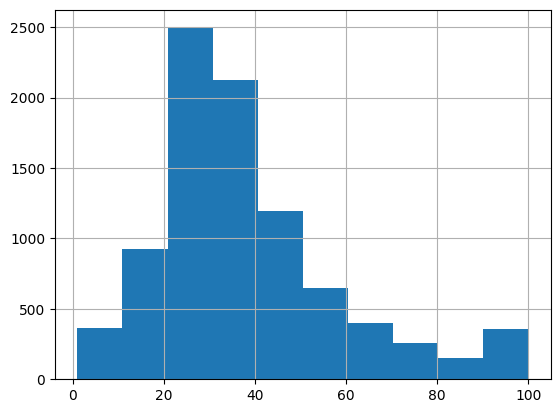

In [6]:
train["Pawpularity"].hist()
plt.show()



In [7]:
tabular_columns = [
    "Subject Focus",
    "Eyes",
    "Face",
    "Near",
    "Action",
    "Accessory",
    "Group",
    "Collage",
    "Human",
    "Occlusion",
    "Info",
    "Blur",
]




In [8]:
def preprocess_image(image_url):
    image_string = tf.io.read_file(image_url)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.central_crop(image, 1.0)
    image = tf.image.resize(image, (Config.image_size, Config.image_size))
    return image




In [9]:
def preprocess(image_url, tabular):
    image = preprocess_image(image_url)
    # tabular is a row containing [Pawpularity] + tabular_columns
    # return ((image, tabular_features), y)
    return (image, tabular[1:]), tabular[0]




In [10]:
# Fix for TF/Keras 2.18:
# keras.layers.experimental.preprocessing.* was removed; use keras.layers.RandomRotation/RandomZoom.
augmentation_layer = keras.Sequential(
    [
        keras.layers.Input(shape=Config.input_shape),
        keras.layers.RandomRotation(factor=0.02),
        keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="augmentation",
)




2026-01-22 07:12:54.082604: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1769065974.082982      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [11]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x




In [12]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches




(128, 128, 3)


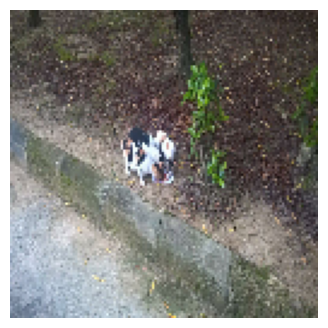

(1, 128, 128, 3)
Image size: 128 X 128
Patch size: 16 X 16
Patches per image: 64
Elements per patch: 768


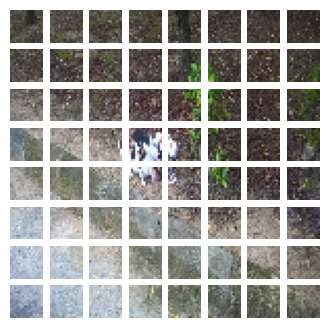

In [13]:
index = np.random.choice(train.shape[0])
plt.figure(figsize=(4, 4))
image = preprocess_image(tf.constant(train.iloc[index]["file_path"], dtype=tf.string))
print(image.shape)
plt.imshow(np.squeeze(image))
plt.axis("off")
plt.show()

resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(Config.image_size, Config.image_size)
)
print(resized_image.shape)
patches = Patches(Config.patch_size)(resized_image)
print(f"Image size: {Config.image_size} X {Config.image_size}")
print(f"Patch size: {Config.patch_size} X {Config.patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (Config.patch_size, Config.patch_size, 3))
    plt.imshow(patch_img.numpy())
    plt.axis("off")
plt.show()




In [14]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded




In [15]:
def create_vision_transformer(use_tabular_inputs=False):
    # Fix: Keras Input expects shape tuple, not a bare int.
    tabular_inputs = tf.keras.Input(shape=(len(tabular_columns),), name="tabular")
    inputs = layers.Input(shape=Config.input_shape, name="image")

    augmented = augmentation_layer(inputs)
    patches = Patches(Config.patch_size)(augmented)
    encoder_patches = PatchEncoder(Config.num_patches, Config.projection_dim)(patches)

    for _ in range(Config.transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoder_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=Config.num_heads,
            key_dim=Config.projection_dim,
            dropout=0.1,
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoder_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=Config.transformer_units, dropout_rate=0.1)
        encoder_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoder_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    features = mlp(representation, hidden_units=Config.mlp_head_units, dropout_rate=0.5)

    if use_tabular_inputs:
        image_x = layers.Dense(128, activation=tf.nn.gelu)(features)
        tabular_x = mlp(tabular_inputs, hidden_units=[16] * 10, dropout_rate=0.5)
        x = tf.keras.layers.Concatenate(axis=1)([image_x, tabular_x])
    else:
        x = features

    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs=[inputs, tabular_inputs], outputs=outputs)
    return model




In [16]:
model = create_vision_transformer(True)
model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 128, 128,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 768) │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     53,312 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_3[0][0]   

 Total params: 11,341,873 (43.27 MB)

 Trainable params: 11,341,873 (43.27 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
image = np.random.normal(size=(1, Config.image_size, Config.image_size, 3)).astype(
    np.float32
)
tabular = np.random.normal(size=(1, len(tabular_columns))).astype(np.float32)
print(image.shape, tabular.shape)
print(model((image, tabular)).shape)



(1, 128, 128, 3) (1, 12)
(1, 1)


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - loss: 1299.8723 - mae: 23.8807 - mape: 100.9922 - rmse: 34.8426
Epoch 1: val_rmse improved from inf to 21.07455, saving model to model_4.weights.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 72s 950ms/step - loss: 1289.8203 - mae: 23.7863 - mape: 100.7321 - rmse: 34.7044 - val_loss: 444.1366 - val_mae: 15.2703 - val_mape: 75.1719 - val_rmse: 21.0745 - learning_rate: 0.0010
Epoch 2/30
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 463.2025 - mae: 16.0683 - mape: 77.3090 - rmse: 21.5202
Epoch 2: val_rmse did not improve from 21.07455
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 463.1082 - mae: 16.0668 - mape: 77.3629 - rmse: 21.5181 - val_loss: 452.9378 - val_mae: 15.0919 - val_mape: 71.3569 - val_rmse: 21.2823 - learning_rate: 0.0010
Epoch 3/30
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 455.8363 - mae: 15.9270 - mape: 76.4737 - rmse: 21.3493
Epoch 3: val_rmse did not improve from 21.07455

Epoch 3: ReduceLROnPlateau reducing learning rate t

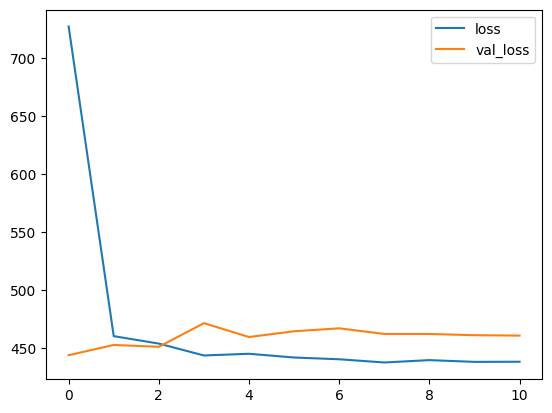

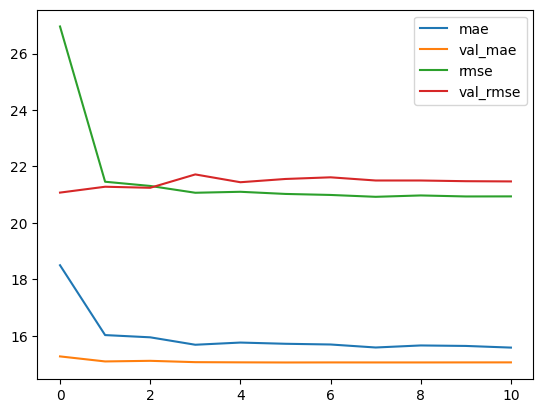

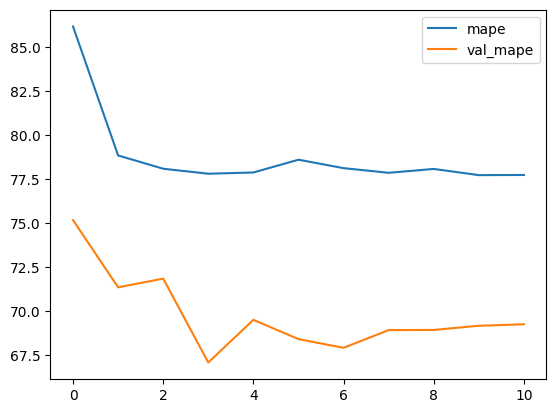

Trained models: 1


In [18]:
tf.keras.backend.clear_session()
models = []
historys = []

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
train_best_fold = True
best_fold = 4

for index, (train_indices, val_indices) in enumerate(kfold.split(train)):
    if train_best_fold and index != best_fold:
        continue

    x_train = train.loc[train_indices, "file_path"].values
    tabular_train = (
        train.loc[train_indices, ["Pawpularity"] + tabular_columns]
        .astype(np.float32)
        .values
    )

    x_val = train.loc[val_indices, "file_path"].values
    tabular_val = (
        train.loc[val_indices, ["Pawpularity"] + tabular_columns]
        .astype(np.float32)
        .values
    )

    # Fix: Keras requires ".weights.h5" suffix when save_weights_only=True
    checkpoint_path = f"model_{index}.weights.h5"
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        save_best_only=True,
        save_weights_only=True,
        monitor="val_rmse",
        mode="min",
        verbose=1,
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        min_delta=1e-4,
        patience=10,
        monitor="val_rmse",
        mode="min",
        restore_best_weights=False,
        verbose=1,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        monitor="val_rmse",
        mode="min",
        verbose=1,
    )
    callbacks = [early_stop, checkpoint, reduce_lr]

    loss = tf.keras.losses.MeanSquaredError()

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=Config.learning_rate,
        weight_decay=Config.weight_decay,
    )

    train_ds = (
        tf.data.Dataset.from_tensor_slices((x_train, tabular_train))
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(512, seed=SEED, reshuffle_each_iteration=True)
        .batch(Config.batch_size)
        .cache()
        .prefetch(tf.data.AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((x_val, tabular_val))
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(Config.batch_size)
        .cache()
        .prefetch(tf.data.AUTOTUNE)
    )

    model = create_vision_transformer(use_tabular_inputs=True)
    model.compile(
        loss=loss,
        optimizer=optimizer,
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae", "mape"],
    )

    history = model.fit(
        train_ds, epochs=Config.num_epochs, validation_data=val_ds, callbacks=callbacks
    )

    for metrics in [
        ("loss", "val_loss"),
        ("mae", "val_mae", "rmse", "val_rmse"),
        ("mape", "val_mape"),
        ["lr"],
    ]:
        cols = [m for m in metrics if m in history.history]
        if len(cols) > 0:
            pd.DataFrame(history.history, columns=cols).plot()
            plt.show()

    model.load_weights(checkpoint_path)
    historys.append(history)
    models.append(model)

print("Trained models:", len(models))




In [19]:
# Fix: remove heavy debug printing per element; it makes test pipeline extremely slow and can time out.
def preprocess_test_data(image_url, tabular):
    image = preprocess_image(image_url)
    return (image, tabular), 0.0


test_ds = (
    tf.data.Dataset.from_tensor_slices(
        (test["file_path"].values, test[tabular_columns].astype(np.float32).values)
    )
    .map(preprocess_test_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Config.batch_size)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)



In [20]:
use_best_result = True

if len(models) == 0:
    raise RuntimeError(
        "No models were trained; cannot generate predictions. Check training loop conditions."
    )

if use_best_result:
    if train_best_fold:
        best_model = models[0]
    else:
        best_fold_idx = 0
        best_score = 1e18
        for fold, history in enumerate(historys):
            if "val_rmse" not in history.history:
                continue
            for val_rmse in history.history["val_rmse"]:
                if val_rmse < best_score:
                    best_score = val_rmse
                    best_fold_idx = fold
        print("Best Score:%.4f Best Fold: %d" % (best_score, best_fold_idx + 1))
        best_model = models[best_fold_idx]

    preds = best_model.predict(test_ds, verbose=1).reshape(-1)
else:
    total_results = [m.predict(test_ds, verbose=1).reshape(-1) for m in models]
    preds = np.mean(total_results, axis=0).reshape(-1)

# Small, metric-consistent postprocessing: Pawpularity is in [0, 100]
preds = np.clip(preds, 0.0, 100.0)

sample_submission["Pawpularity"] = preds
sample_submission.to_csv("submission.csv", index=False)

print(sample_submission.head())
print("Wrote submission.csv with shape:", sample_submission.shape)
print("submission.csv exists:", os.path.exists("submission.csv"))

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 588ms/step
                                 Id  Pawpularity
0  ee51b99832f1ba868f646df93d2b6b81    36.247940
1  caddfb3f8bff9c4b95dbe022018eea21    36.060364
2  582eeabd4a448a53ebb79995888a4b0b    36.221245
3  afc1ad7f0c5eea880759d09e77f7deee    36.155823
4  d5bdf3446e86ce4ec67ce7a00f1cccc2    36.102940
Wrote submission.csv with shape: (992, 2)
submission.csv exists: True
